<a href="https://colab.research.google.com/github/svetlana-voskr/astro_practice/blob/lana/Hipparos/hipparos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Hipparcos Star Astronomy Catalog



The data has been collected by the European Space Agency's astrometric satellite , [Hipparcos](https://www.n2yo.com/satellite/?s=20169) , active from August 1989 to August 1993 .

The catalog was published on July 1997 .

**Bibcode:** [1997HIP…C……0E](https://cdsarc.unistra.fr/viz-bin/cat/I/239)

Based on:


*   https://www.kaggle.com/code/ctzenscientist/astronomy-101-with-hipparchos-catalogue
*   https://www.kaggle.com/datasets/konivat/hipparcos-star-catalog/data



## Import packages

In [ ]:
!pip install smplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 424.1/424.1 kB 5.0 MB/s eta 0:00:00


In [ ]:
!pip install astroquery

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 994.8/994.8 kB 60.0 MB/s eta 0:00:00


In [ ]:
!pip install mplcyberpunk

In [ ]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, smplotlib, seaborn as sns
from astroquery.vizier import Vizier

import mplcyberpunk

plt.style.use("cyberpunk")
#plt.style.use("dark_background")
#plt.style.use('https://github.com/dhaitz/matplotlib-stylesheets/raw/master/pitayasmoothie-light.mplstyle')

## Download the data from [Vizier](https://vizier.cds.unistra.fr/viz-bin/Cat?I/239)

In [ ]:
df = Vizier(row_limit=-1,
            columns=['Vmag', 'RAICRS',	'DEICRS',	'Plx',	'pmRA',	'pmDE',	'e_Plx',	'B-V',	'SpType','Period', 'V-I']).get_catalogs(catalog='I/239/hip_main')
df = df[df.keys()[0]]
df = df.to_pandas()
df.head()

,Vmag,RAICRS,DEICRS,Plx,pmRA,pmDE,e_Plx,B-V,SpType,Period,V-I
0,9.10,0.000912,1.089013,3.54,-5.20,-1.88,1.39,0.482,F5,NaN,0.55
1,9.27,0.003797,-19.498837,21.90,181.21,-0.93,3.10,0.999,K3V,NaN,1.04
2,6.61,0.005008,38.859286,2.81,5.24,-2.91,0.63,-0.019,B9,NaN,0.00
3,8.06,0.008382,-51.893546,7.75,62.85,0.16,0.97,0.370,F0V,NaN,0.43
4,8.55,0.009965,-40.591224,2.87,2.53,9.07,1.11,0.902,G8III,NaN,0.90


## Exploratory data analysis

In [ ]:
df.describe()

,Vmag,RAICRS,DEICRS,Plx,pmRA,pmDE,e_Plx,B-V,Period,V-I
count,118217.000000,117955.000000,117955.000000,117955.000000,117955.000000,117955.000000,117955.000000,116937.000000,2541.000000,116943.000000
mean,8.373233,181.466380,-2.143250,7.215220,-1.303405,-16.599682,1.361105,0.706396,46.637493,0.762693
std,1.312035,103.261685,41.016397,11.286060,98.199404,93.859400,1.779434,0.489819,112.446739,0.563381
min,-1.440000,0.000912,-89.782454,-54.950001,-4410.790000,-5813.000000,0.380000,-0.400000,0.050000,-0.490000
25%,7.640000,93.425334,-36.636503,2.510000,-15.150000,-21.740000,0.880000,0.347000,0.730000,0.410000
50%,8.440000,181.969874,-1.945926,4.610000,-1.680000,-5.650000,1.100000,0.612000,2.410000,0.680000
75%,9.150000,271.744455,31.435615,8.410000,11.840000,3.760000,1.390000,1.078000,9.430000,1.050000
max,14.080000,359.978792,89.569409,772.330017,6767.260000,10326.930000,114.459999,5.460000,936.070007,9.030000


<Axes: >

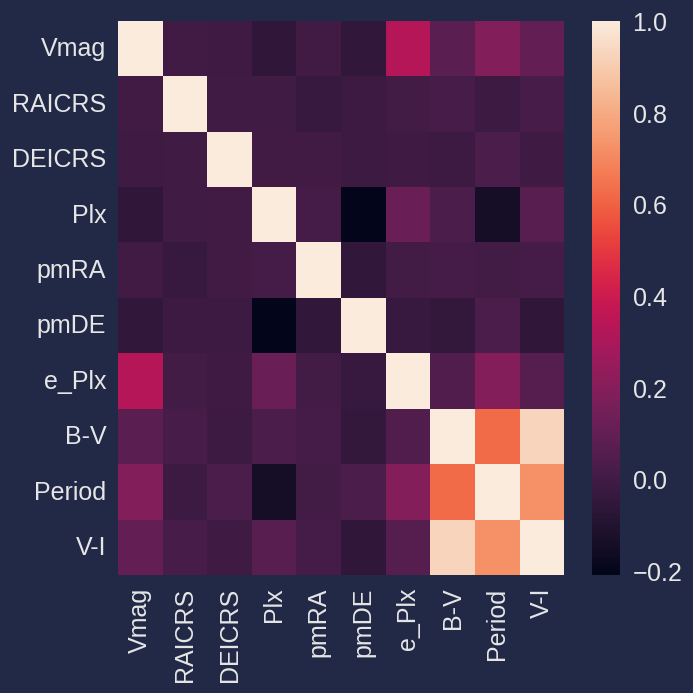

In [ ]:
sns.heatmap(df.drop(['SpType'], axis=1).corr())

## [Hertzsprung–Russell diagram](https://en.wikipedia.org/wiki/Hertzsprung–Russell_diagram)

Calculate absolute magnitude:
$$ M = V_{mag} -5\cdot log_{10}( \pi [pc]/10) + 5$$

In [ ]:
df['M'] = df["Vmag"]-5*np.log10(1/df["Plx"]*1000/10) + 5

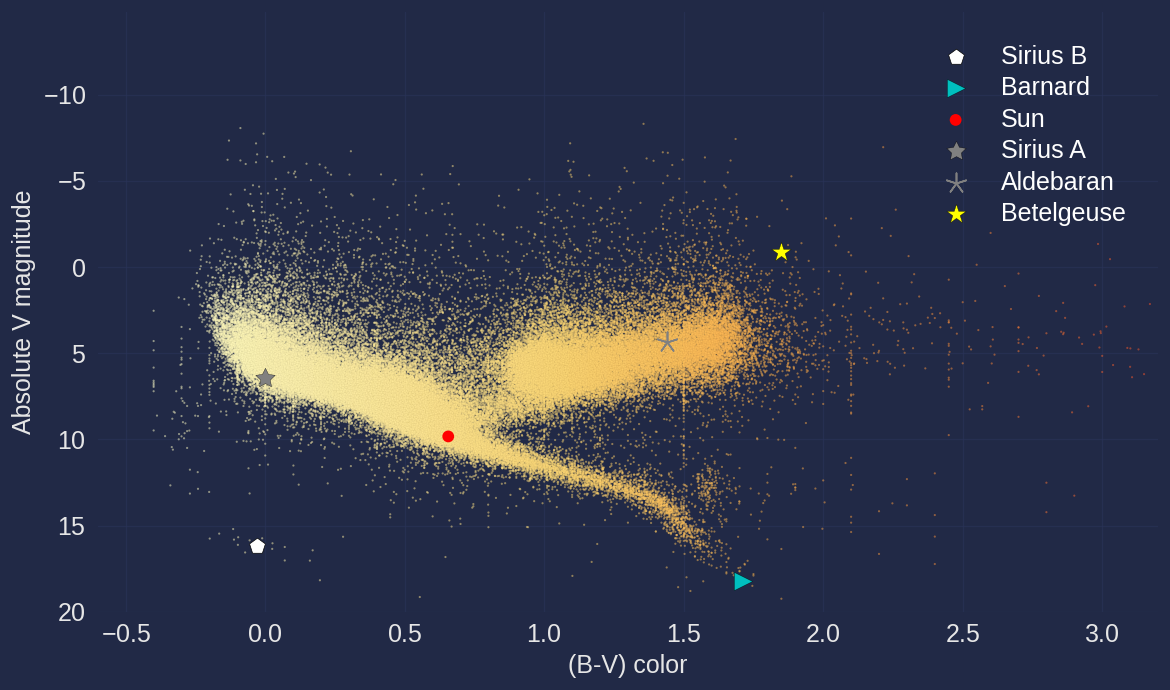

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(df["B-V"], df["M"], c=df["B-V"], alpha=0.5, cmap = "YlOrRd", marker = '.', s = 7, linewidth = 0.01)
ax.scatter(x = -0.03, y = 11.18+5, c = "white", marker = (5, 0), s = 100, linewidth = 0.4, label = "Sirius B")
ax.scatter(x = 1.713, y = 13.21+5, c = "c", marker = '>', s = 120, linewidth = 0.2, label = "Barnard")
ax.scatter(x = 0.656, y = 4.83+5, c = "red", facecolors='none', edgecolor='none', marker = 'o', s = 50, linewidth = 0.4, label = "Sun")
ax.scatter(x = 0, y = 1.42+5, c = "gray", marker = (5, 1), s = 150, linewidth = 0.2, label = "Sirius A")
ax.scatter(x = 1.44, y = -0.641+5, c = "grey", marker = (5, 2), s = 150, linewidth = 1, label = "Aldebaran")
ax.scatter(x = 1.85, y = -5.85+5, c = "yellow", marker = '*', s = 150, linewidth = 0.2, label = "Betelgeuse")

plt.xlabel("(B-V) color")
plt.ylabel(r"Absolute V magnitude")
#ax.set_title("Hertzsprung - Russell diagram")
ax.set(xlim=(-0.6, 3.2), ylim=(20, -14.8))
plt.legend(labelcolor = "white")
plt.tight_layout()
plt.show()

## [Spectral Types](https://en.wikipedia.org/wiki/Stellar_classification)
Having understood one of the primary attributes that help astronomers study stars, we now explore another property of stars. We call this property "spectral types" and provide us a way to classify stars based on certain criteria.

Spectral types (referred to as SpType in the catalog) of stars are a way to classify stars with the O-Type stars being the hottest and the M-Type stars being the coldest.

In [ ]:
len(df["SpType"].unique())

4125

We do have a problem now. We see that there are about 4125 types of spectral types (The Length attribute reads 4125). This is because there are sub classes of stars within the measured spectral type depending on various parameters (variability, metallicity, etc.) which is beyond the scope of this analysis. Plotting this directly does not give us much information

Since our attempt of plotting the raw spectral types failed miserably, we need a smarter way to get the statistics we are looking forward to. To get an understanding of the spectral types from the catalogue we extract out the first letter from the spectral type information to get an idea of how frequently a spectral type appears in the catalog data.

To do this, we define a function that takes in the dictionary of spectral types obtained above and then count the number of stars in each spectral type.

In [ ]:
def classify_star_type(sptype):
    if isinstance(sptype, str):
        if "O" in sptype:
            return "O"
        elif "B" in sptype:
            return "B"
        elif "A" in sptype:
            return "A"
        elif "F" in sptype:
            return "F"
        elif "G" in sptype:
            return "G"
        elif "K" in sptype:
            return "K"
        elif "M" in sptype:
            return "M"
    return "Others"

df["Star Type"] = df["SpType"].apply(classify_star_type)

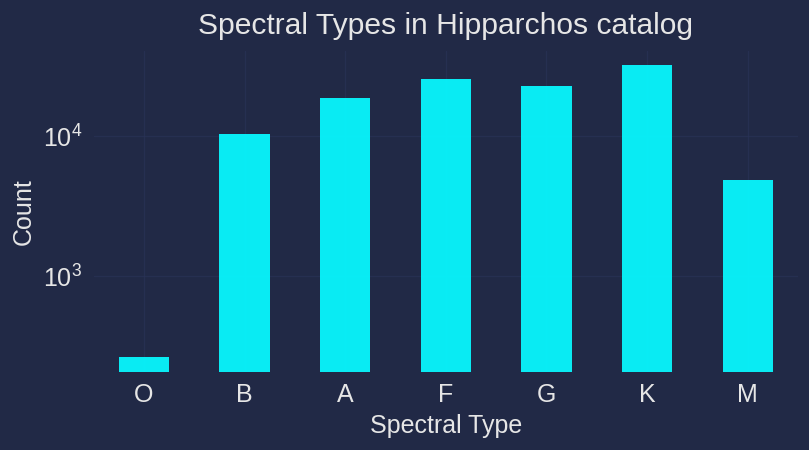

In [ ]:
sptype = df["SpType"].str[0].value_counts().sort_index()[['O', 'B', 'A', 'F', 'G', 'K', 'M']]
fig, ax = plt.subplots(figsize=(7, 4))
sptype.plot(kind='bar', ax=ax, alpha=0.95)
ax.set(xlabel="Spectral Type", ylabel="Count", yscale='log')
plt.xticks(rotation=0)
plt.title ("Spectral Types in Hipparchos catalog")
plt.tight_layout()
plt.show()

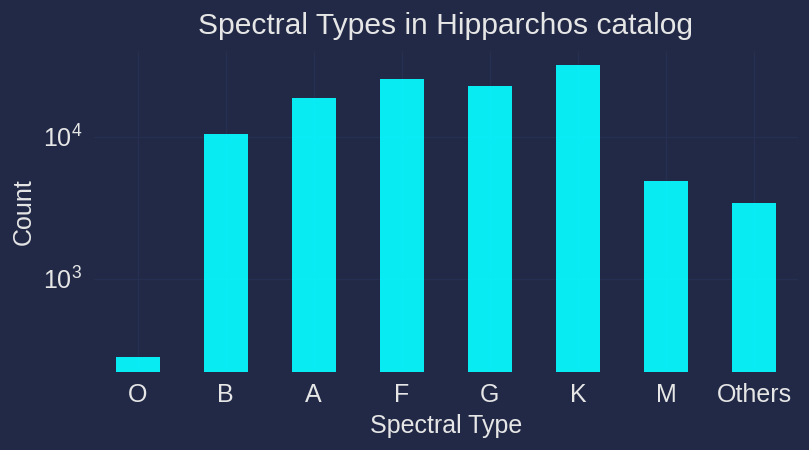

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
df['Star Type'].value_counts().sort_index()[['O', 'B', 'A', 'F', 'G', 'K', 'M', 'Others']].plot(kind='bar', ax=ax, alpha=0.95)
ax.set(xlabel="Spectral Type", ylabel="Count", yscale='log')
plt.xticks(rotation=0)
plt.title ("Spectral Types in Hipparchos catalog")
plt.tight_layout()
plt.show()

The variability types means the following,

C : no variability detected ("constant")

D : duplicity-induced variability

M : possibly micro-variable, with amplitude < 0.03 mag (stars classified with high confidence as micro-variable are flagged U)

P : periodic variable

R : the V-I color index was revised during the variability analysis

U : unsolved variable which does not fall in the other categories; this class also includes irregular or semi-regular variables, and possibly variables with amplitude > or ~ 0.03 mag

## Температура

Let's calculate temperature by using  Ballesteros' formula.

$$T = 4600 K \left(\frac{1}{0.92(B - V)+1.7}+\frac{1}{0.92(B−V)+0.62)}\right)$$

In [ ]:
df["Temperature (K)"] = 4600 * ((1 / (0.92 * df["B-V"] + 1.7)) + (1 / (0.92* df["B-V"] + 0.62)))

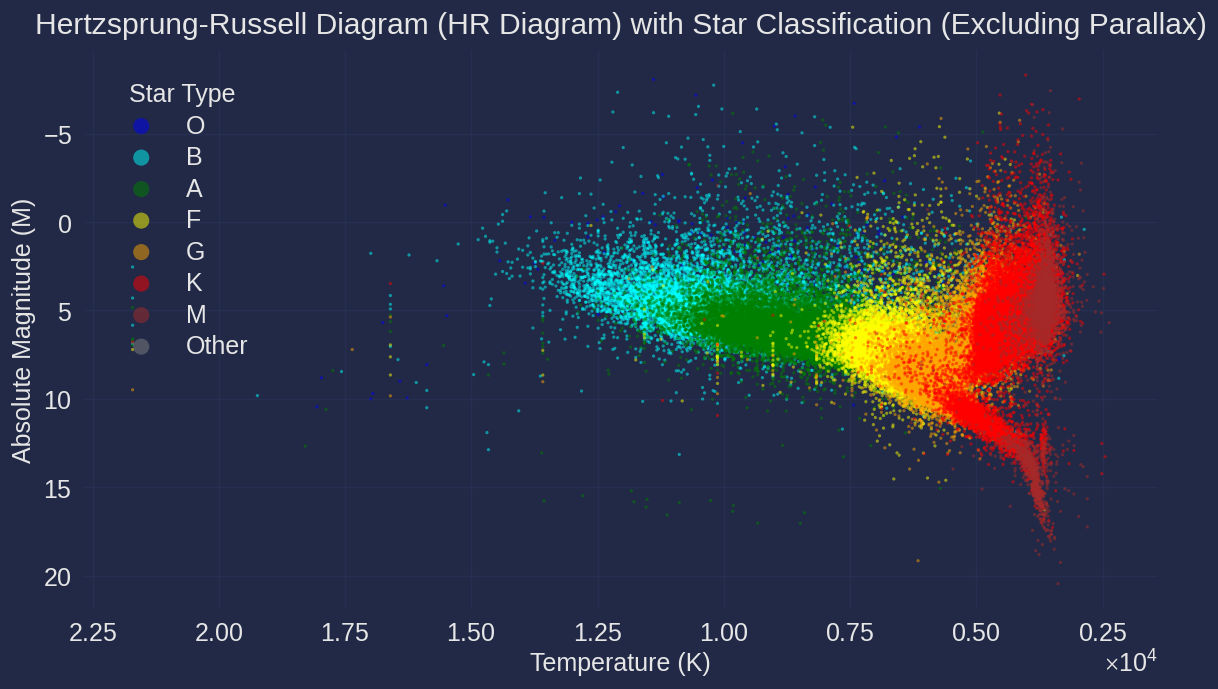

In [ ]:
plt.figure(figsize=(10, 6))

star_colors = {"O": "blue", "B": "cyan", "A": "green", "F": "yellow", "G": "orange", "K": "red", "M": "brown", "Other": "gray"}

for star_type, color in star_colors.items():
    filtered_df = df[df["Star Type"] == star_type]
    plt.scatter(filtered_df["Temperature (K)"], filtered_df["M"], label=star_type, marker='.', c=color, s=15, alpha=0.5, edgecolor='none')

plt.xlabel('Temperature (K)')
plt.ylabel('Absolute Magnitude (M)')
plt.title('Hertzsprung-Russell Diagram (HR Diagram) with Star Classification (Excluding Parallax)')
plt.legend(title='Star Type', facecolor="white", markerscale=5)
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
plt.grid(True)
plt.tight_layout()
plt.show()

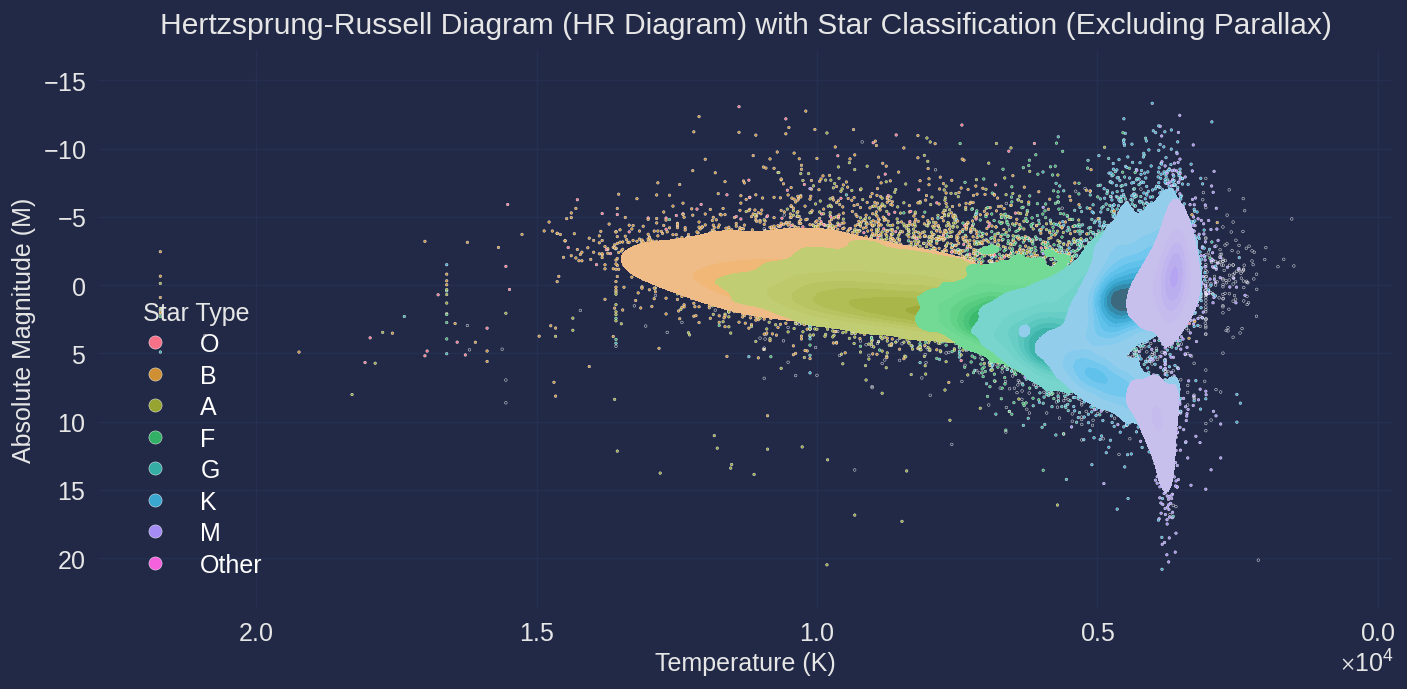

In [ ]:
plt.figure(figsize=(12, 6))
hue_order=["O", "B", "A", "F", "G", "K", "M", "Other"]

sns.scatterplot(data=df, x="Temperature (K)", y=df["Vmag"]-5*np.log10(1/df["Plx"]*1000/10 - 1), s=10, marker='.', hue="Star Type", hue_order=hue_order, legend=True)
sns.kdeplot(data=df, x="Temperature (K)", y=df["Vmag"]-5*np.log10(1/df["Plx"]*1000/10 - 1), fill=True, hue="Star Type", hue_order=hue_order, legend=True)

plt.xlabel('Temperature (K)')
plt.ylabel('Absolute Magnitude (M)')
plt.title('Hertzsprung-Russell Diagram (HR Diagram) with Star Classification (Excluding Parallax)')
plt.legend(title='Star Type', labelcolor='white', markerscale=5)
plt.grid(True)
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## Proper Motion of stars¶

We now visualize the proper motion of the stars as captured by the Hipparchos mission.

Distant stars on the celestial sphere appear to remain fixed, however, most of the stars in the solar neighborhood appear to move across the celestial sphere since these stars are closer. This apparent motion of stars with respect to the fixed stars in the background is called the proper motion.

Proper motion is measured along the Right Ascension (pmRA) and along the Declination (pmDE) and these are measured in mas per year ($mas \cdot year^{-1}$), where mas is milliarcseconds, a common unit used to measure very small angles in the sky.

$$1 mas = 10^{-3} arcsec$$

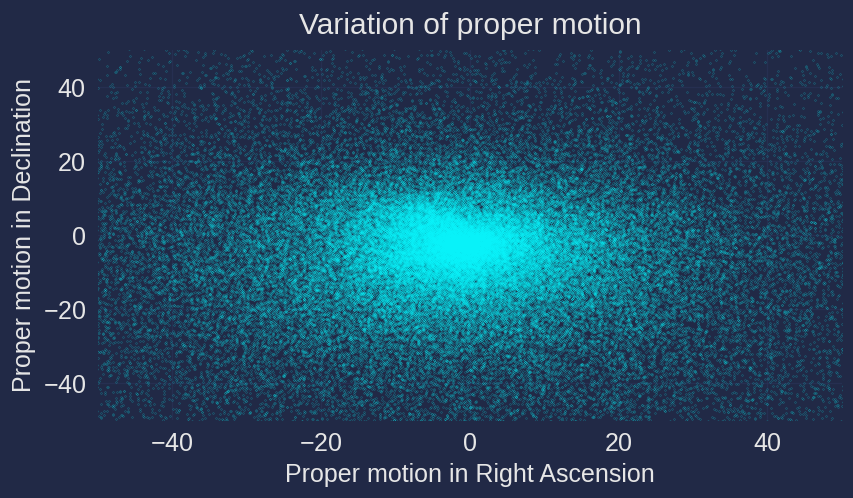

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
plt.plot(df["pmRA"], df["pmDE"], 'o', alpha=0.5, markersize = 0.2)
#sns.kdeplot(data=df, x="pmRA", y="pmDE", levels=[0.2, 0.5, 0.8, 0.95], linewidths=1)
ax.set(xlabel="Proper motion in Right Ascension",
       ylabel="Proper motion in Declination", title = "Variation of proper motion")
plt.xlim(-50, 50)
plt.ylim(-50, 50)
plt.show()

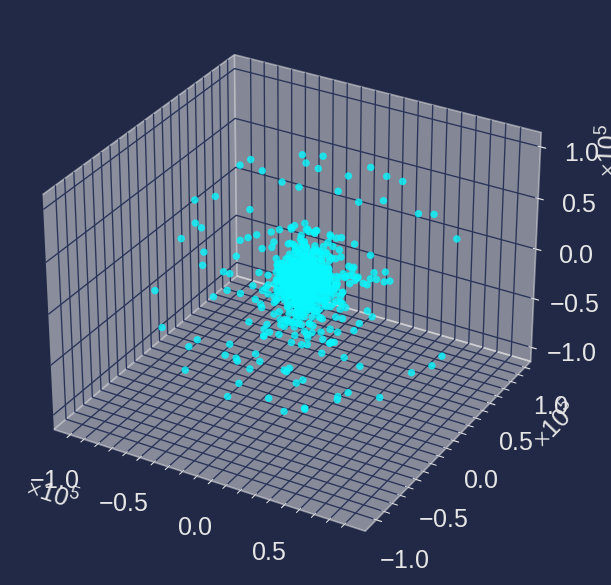

In [ ]:
x = 1/df['Plx']*1000*np.cos(df["pmRA"])*np.sin(np.pi/2-df["pmDE"])
y = 1/df['Plx']*1000*np.sin(df["pmRA"])*np.sin(np.pi/2-df["pmDE"])
z = 1/df['Plx']*1000*np.cos(np.pi/2-df["pmDE"])

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x,y,z,'.', edgecolors='none', alpha=0.8)
plt.show()

## Parallax

In [ ]:
def get_grouped_df(df):
    distance = np.arange(0, 8.4, 0.1)
    start_distance = df.distance.min()
    e_plx_median = []
    for dist in distance:
        df_ = df[(df.distance <= dist) & (df.distance > start_distance)]
        e_plx_median.append(np.nanmedian(df_["e_Plx"]))
        start_distance = dist

    grouped_df = pd.DataFrame({'distance': distance, 'e_Plx': e_plx_median})
    return grouped_df

In [ ]:
df['distance'] = 1/df['Plx']

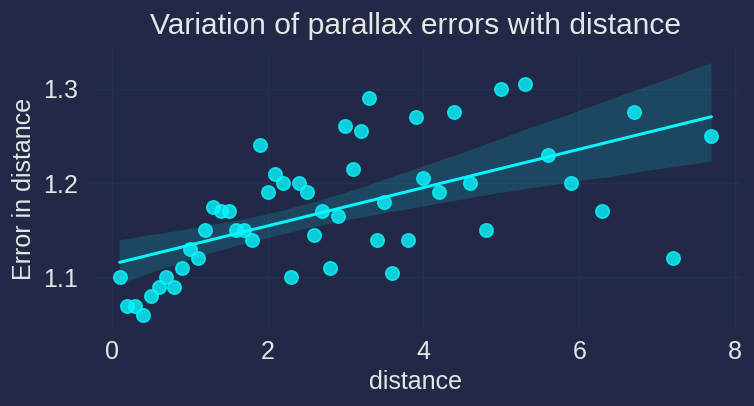

In [ ]:
plt.figure(figsize=(7, 3))
sns.regplot(x = 'distance',
            y = "e_Plx", data=get_grouped_df(df[df.Plx > 0])).set_title("Variation of parallax errors with distance")
plt.ylabel('Error in distance')
plt.show()

## Histogram on stellar period

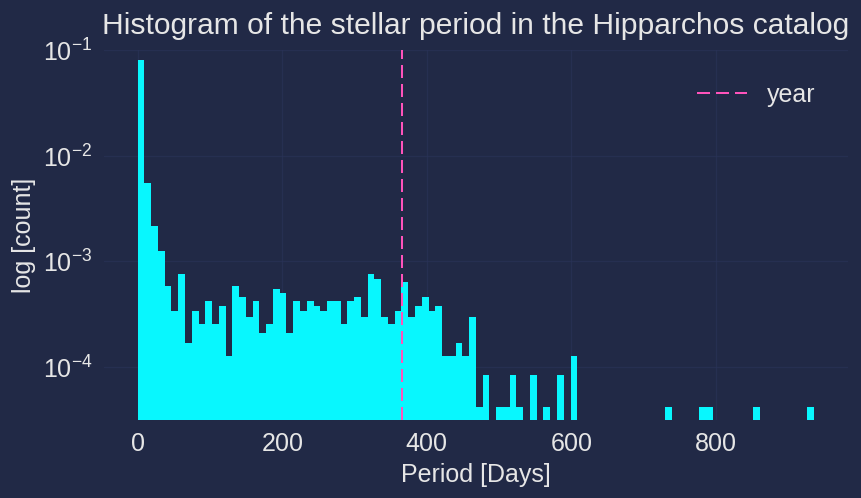

In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
plt.hist(df["Period"], bins=100, log = True, density=True)
#sns.kdeplot(df["Period"], log_scale=(False, True), ax =ax)
plt.plot(365.25*np.ones(100), np.logspace(-4.5, -1, 100), '--', label='year')
plt.xlabel("Period [Days]")
plt.ylabel("log [count]")
plt.legend()
plt.ylim(10**(-4.5), 1e-1)
plt.title("Histogram of the stellar period in the Hipparchos catalog")
plt.show()